# ROUND 3 — Data Visualization

Dataset: `data/ROUND_3/` (3 days, prices + trades).

Instruments:
- **VELVETFRUIT_EXTRACT** — underlying, ~5250
- **HYDROGEL_PACK** — separate instrument, ~10000
- **VEV_{4000..6500}** — call options on VELVETFRUIT_EXTRACT at 10 strikes

A consistent **day palette** is used across every plot so you can trace each day as you scroll.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from pathlib import Path

sns.set_theme(style='white', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 140,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.6,
    'font.family': 'DejaVu Sans',
})

DATA_DIR = Path('../../data/ROUND_3')

# Day palette — warm, distinct, readable on white
DAY_COLORS = {0: '#1b4f8f', 1: '#f28e2b', 2: '#b02a37'}
DAY_CMAP   = mcolors.LinearSegmentedColormap.from_list('days', list(DAY_COLORS.values()))

def day_legend(ax, loc='best', **kw):
    handles = [Line2D([0],[0], color=c, lw=2.5, label=f'Day {d}') for d,c in DAY_COLORS.items()]
    ax.legend(handles=handles, loc=loc, frameon=False, **kw)

: 

In [2]:
# Load all days
prices = pd.concat([
    pd.read_csv(DATA_DIR / f'prices_round_3_day_{d}.csv', sep=';').assign(day=d)
    for d in (0, 1, 2)
], ignore_index=True)

trades = pd.concat([
    pd.read_csv(DATA_DIR / f'trades_round_3_day_{d}.csv', sep=';').assign(day=d)
    for d in (0, 1, 2)
], ignore_index=True)

# Global time index: (day * 1e6) + timestamp keeps the 3 days continuous
prices['t_global'] = prices['day'] * 1_000_000 + prices['timestamp']
trades['t_global'] = trades['day'] * 1_000_000 + trades['timestamp']

VEV_STRIKES = sorted(int(p.split('_')[1]) for p in prices['product'].unique() if p.startswith('VEV_'))
UNDERLYING  = 'VELVETFRUIT_EXTRACT'

print(f'Prices rows: {len(prices):,}    Trades rows: {len(trades):,}')
print(f'Products   : {sorted(prices["product"].unique())}')
print(f'VEV strikes: {VEV_STRIKES}')

Prices rows: 360,000    Trades rows: 4,048
Products   : ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
VEV strikes: [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]


## 1. Underlying & HYDROGEL — mid-price tracks

Three days laid side-by-side. Same y-axis across days so drifts are visible.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), sharey='row', sharex='col')
for col, day in enumerate((0,1,2)):
    for row, prod in enumerate((UNDERLYING, 'HYDROGEL_PACK')):
        ax = axes[row, col]
        sub = prices[(prices['product']==prod) & (prices['day']==day)]
        ax.plot(sub['timestamp']/1000, sub['mid_price'], color=DAY_COLORS[day], lw=0.9)
        ax.fill_between(sub['timestamp']/1000, sub['mid_price'], sub['mid_price'].mean(),
                        color=DAY_COLORS[day], alpha=0.08)
        ax.axhline(sub['mid_price'].mean(), color=DAY_COLORS[day], ls='--', lw=0.8, alpha=0.6)
        if row == 0:
            ax.set_title(f'Day {day}', color=DAY_COLORS[day])
        if col == 0:
            ax.set_ylabel(prod.replace('_','\n'), fontsize=10)
        if row == 1:
            ax.set_xlabel('Time (×1000 ticks)')
fig.suptitle('Mid-price through time — underlying (top) vs HYDROGEL (bottom)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

: 

## 2. The full VEV option chain over time

Each strike gets its own track. Log scale on y makes the deep-OTM wings visible next to the deep-ITM legs.

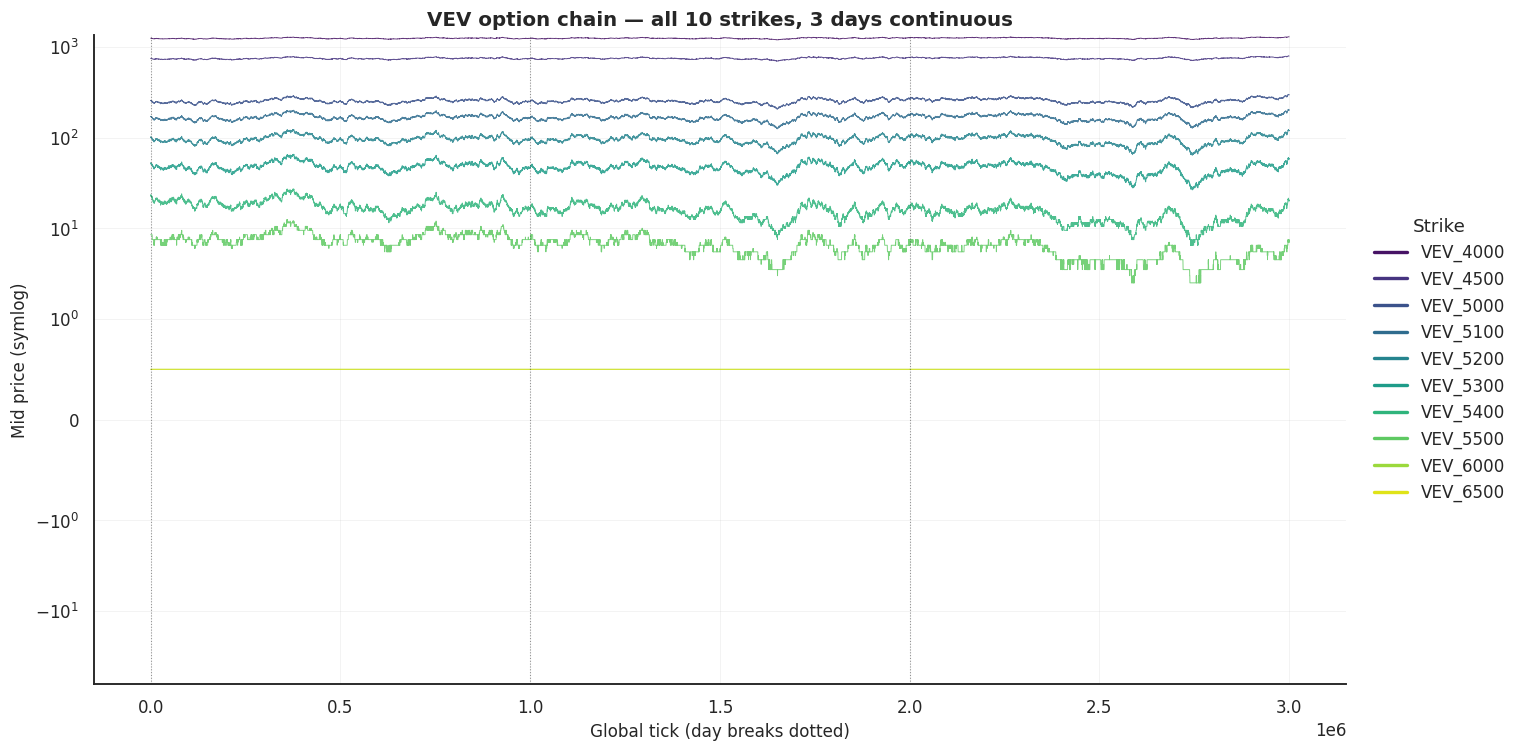

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))
strike_cmap = plt.cm.viridis(np.linspace(0.05, 0.95, len(VEV_STRIKES)))

for d in (0,1,2):
    offset = d * 1_000_000
    for color, k in zip(strike_cmap, VEV_STRIKES):
        sub = prices[(prices['product']==f'VEV_{k}') & (prices['day']==d)]
        ax.plot(sub['timestamp'] + offset, sub['mid_price'],
                color=color, lw=0.6, alpha=0.85)
    ax.axvline(offset, color='#333', lw=0.7, ls=':', alpha=0.5)

ax.set_yscale('symlog', linthresh=1)
ax.set_xlabel('Global tick (day breaks dotted)')
ax.set_ylabel('Mid price (symlog)')
ax.set_title('VEV option chain — all 10 strikes, 3 days continuous')

# Strike color legend
handles = [Line2D([0],[0], color=c, lw=2.2, label=f'VEV_{k}') for c,k in zip(strike_cmap, VEV_STRIKES)]
ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, title='Strike')
plt.tight_layout()
plt.show()

## 3. The smile — option price vs strike

For each day, sample evenly across the session and plot price vs strike. A bundle of curves per day reveals how the smile shape moves.

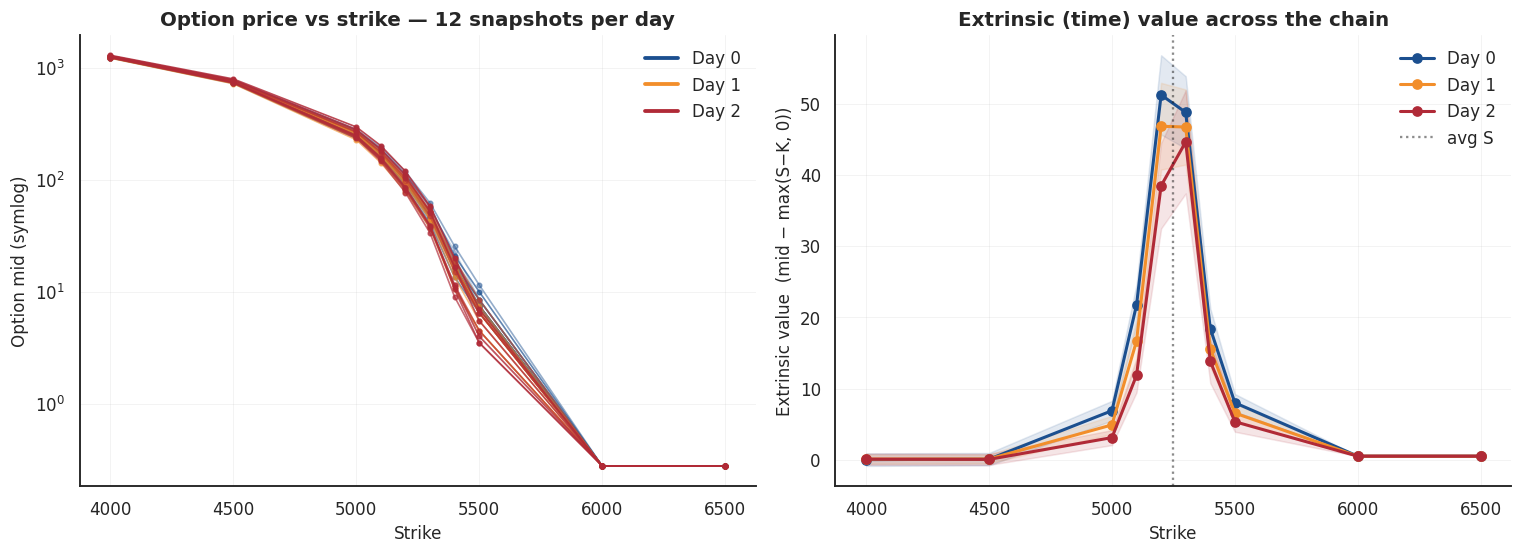

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# Left panel: prices vs strike
ax = axes[0]
N_SAMPLES = 12
for d in (0,1,2):
    day_df = prices[prices['day']==d]
    tmax = day_df['timestamp'].max()
    sample_ts = np.linspace(0, tmax, N_SAMPLES).astype(int)
    sample_ts = day_df['timestamp'].unique()[
        np.searchsorted(np.sort(day_df['timestamp'].unique()), sample_ts)
    ]
    for i, t in enumerate(sample_ts):
        row = day_df[day_df['timestamp']==t]
        vev = row[row['product'].str.startswith('VEV_')].copy()
        vev['strike'] = vev['product'].str.split('_').str[1].astype(int)
        vev = vev.sort_values('strike')
        alpha = 0.25 + 0.6 * (i/(N_SAMPLES-1))
        ax.plot(vev['strike'], vev['mid_price'], color=DAY_COLORS[d], lw=1.1, alpha=alpha, marker='o', ms=3)
ax.set_yscale('symlog', linthresh=1)
ax.set_xlabel('Strike')
ax.set_ylabel('Option mid (symlog)')
ax.set_title('Option price vs strike — 12 snapshots per day')
day_legend(ax)

# Right panel: extrinsic value (mid - max(S-K, 0))
ax = axes[1]
for d in (0,1,2):
    day_df = prices[prices['day']==d]
    und = day_df[day_df['product']==UNDERLYING].set_index('timestamp')['mid_price']
    N_SAMPLES_EXT = 60
    sample_ts = np.linspace(und.index.min(), und.index.max(), N_SAMPLES_EXT).astype(int)
    sample_ts = und.index[np.searchsorted(und.index, sample_ts)]
    accum = {k: [] for k in VEV_STRIKES}
    for t in sample_ts:
        S = und.loc[t]
        row = day_df[day_df['timestamp']==t]
        for k in VEV_STRIKES:
            r = row[row['product']==f'VEV_{k}']
            if len(r):
                mid = r['mid_price'].iloc[0]
                accum[k].append(mid - max(S - k, 0))
    means = [np.mean(accum[k]) for k in VEV_STRIKES]
    stds  = [np.std(accum[k])  for k in VEV_STRIKES]
    ax.plot(VEV_STRIKES, means, color=DAY_COLORS[d], lw=2, marker='o', label=f'Day {d}')
    ax.fill_between(VEV_STRIKES,
                    np.array(means)-np.array(stds),
                    np.array(means)+np.array(stds),
                    color=DAY_COLORS[d], alpha=0.12)
ax.axvline(prices[prices['product']==UNDERLYING]['mid_price'].mean(), color='k', ls=':', alpha=0.5, label='avg S')
ax.set_xlabel('Strike')
ax.set_ylabel('Extrinsic value  (mid − max(S−K, 0))')
ax.set_title('Extrinsic (time) value across the chain')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 4. Bid–ask spread heatmap

Median spread (ticks) per product × day. Warmer = wider market.

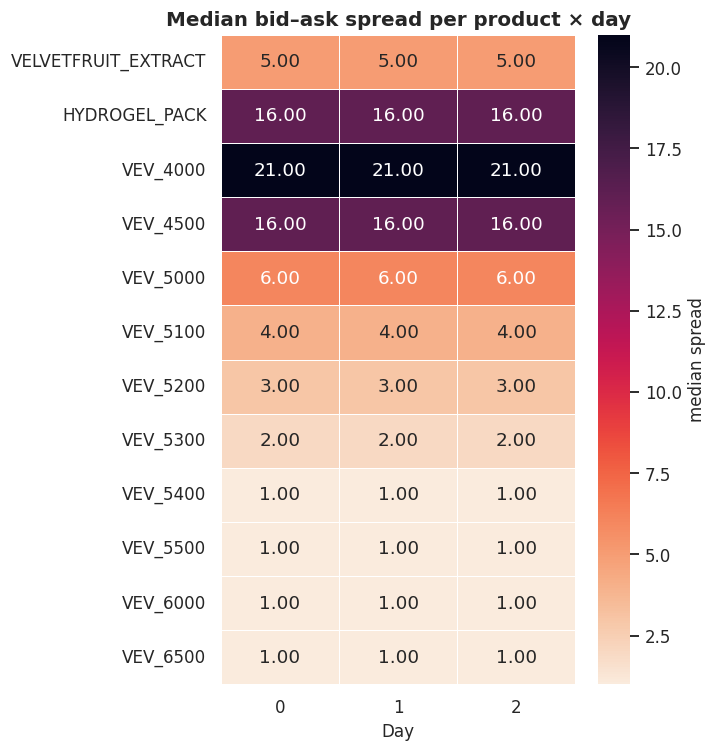

In [6]:
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']
sp = (prices.groupby(['product','day'])['spread']
            .median()
            .unstack('day'))
# Order rows: underlying, hydrogel, then VEV ascending
order = [UNDERLYING, 'HYDROGEL_PACK'] + [f'VEV_{k}' for k in VEV_STRIKES]
sp = sp.reindex(order)

fig, ax = plt.subplots(figsize=(6.5, 7))
sns.heatmap(sp, annot=True, fmt='.2f', cmap='rocket_r', cbar_kws={'label':'median spread'}, ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Median bid–ask spread per product × day')
ax.set_xlabel('Day'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 5. Return distributions, by day

Log-returns of mid-price for the underlying and HYDROGEL. KDE per day with rug ticks — stacks the day-to-day character.

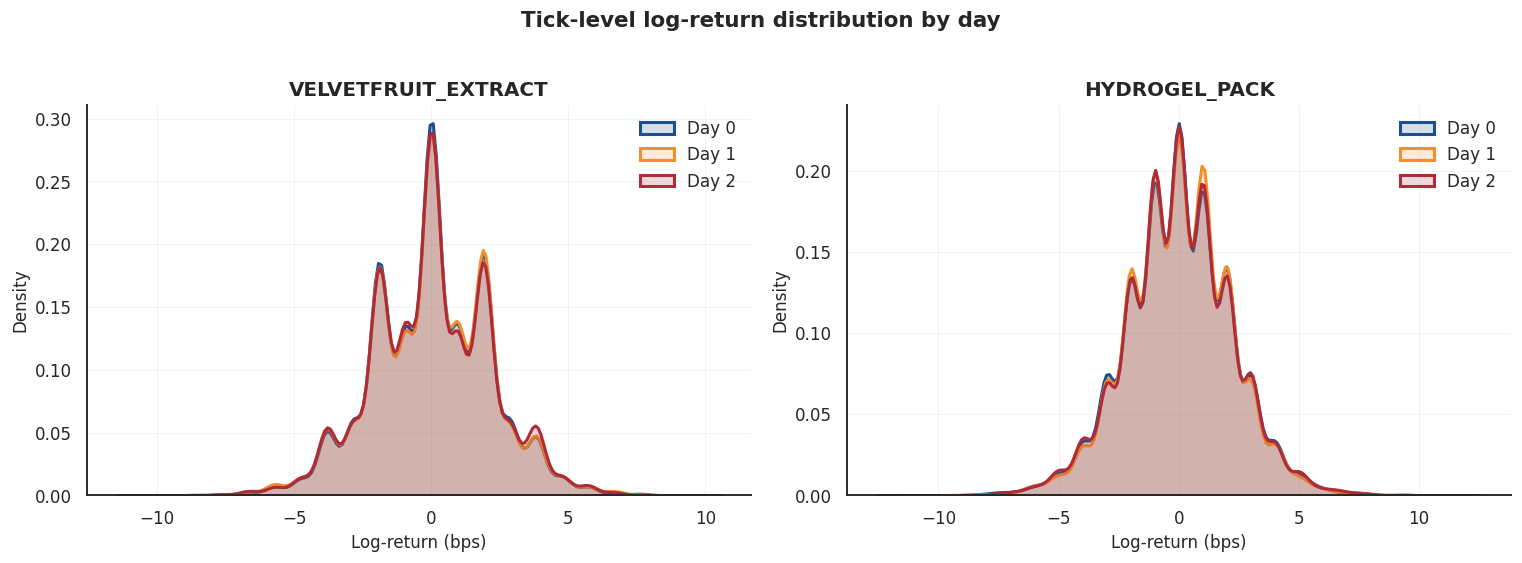

In [7]:
def log_returns(df, product):
    out = []
    for d in (0,1,2):
        s = df[(df['product']==product) & (df['day']==d)].sort_values('timestamp')['mid_price']
        r = np.log(s).diff().dropna()
        out.append(pd.DataFrame({'ret': r.values, 'day': d}))
    return pd.concat(out, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, prod in zip(axes, (UNDERLYING, 'HYDROGEL_PACK')):
    r = log_returns(prices, prod)
    for d in (0,1,2):
        sns.kdeplot(r[r['day']==d]['ret']*1e4, ax=ax, fill=True, alpha=0.18,
                    color=DAY_COLORS[d], lw=2, label=f'Day {d}')
    ax.set_xlabel('Log-return (bps)')
    ax.set_ylabel('Density')
    ax.set_title(f'{prod}')
    ax.legend(frameon=False)
fig.suptitle('Tick-level log-return distribution by day', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Volatility profile — realized σ vs strike

Rolling 100-tick std of log-returns, averaged over each day. Gives a quick sense of how twitchy each strike was.

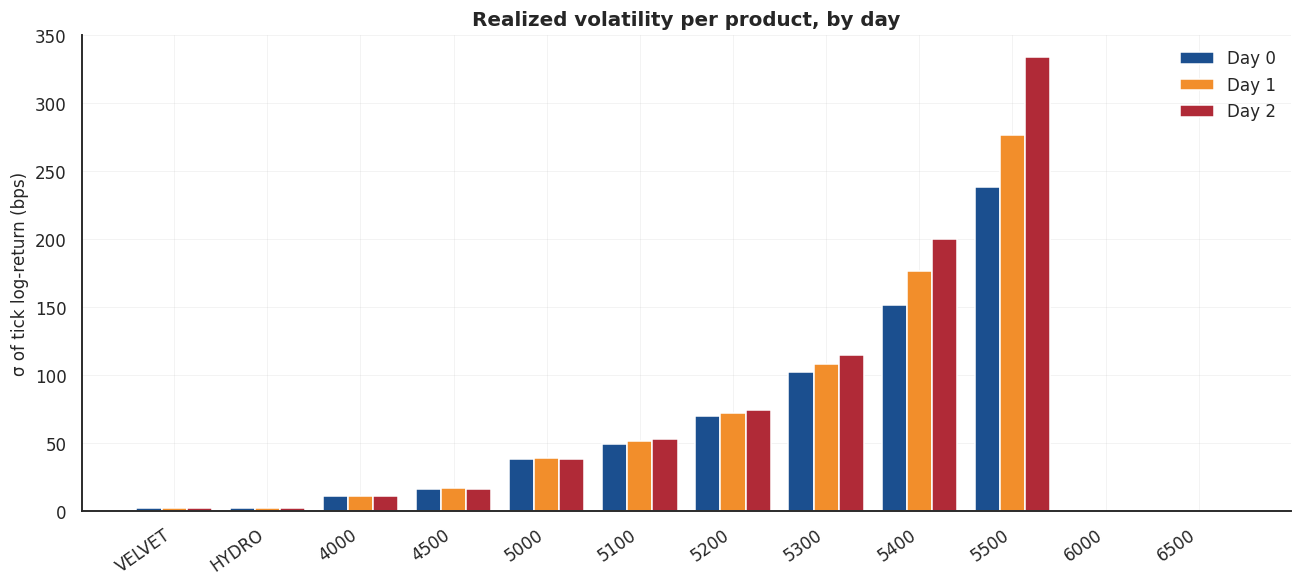

In [8]:
fig, ax = plt.subplots(figsize=(12, 5.5))
products = [UNDERLYING, 'HYDROGEL_PACK'] + [f'VEV_{k}' for k in VEV_STRIKES]
xlabels = ['VELVET', 'HYDRO'] + [str(k) for k in VEV_STRIKES]
x = np.arange(len(products))
width = 0.27
for i, d in enumerate((0,1,2)):
    sigs = []
    for p in products:
        s = prices[(prices['product']==p) & (prices['day']==d)].sort_values('timestamp')['mid_price']
        r = np.log(s).diff().dropna()
        sigs.append(r.std()*1e4)
    ax.bar(x + (i-1)*width, sigs, width=width, color=DAY_COLORS[d], label=f'Day {d}', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=35, ha='right')
ax.set_ylabel('σ of tick log-return (bps)')
ax.set_title('Realized volatility per product, by day')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 7. Cross-product correlation heatmap

Tick-level log-return correlation. VEV options should cluster around their underlying; HYDROGEL should be an island.

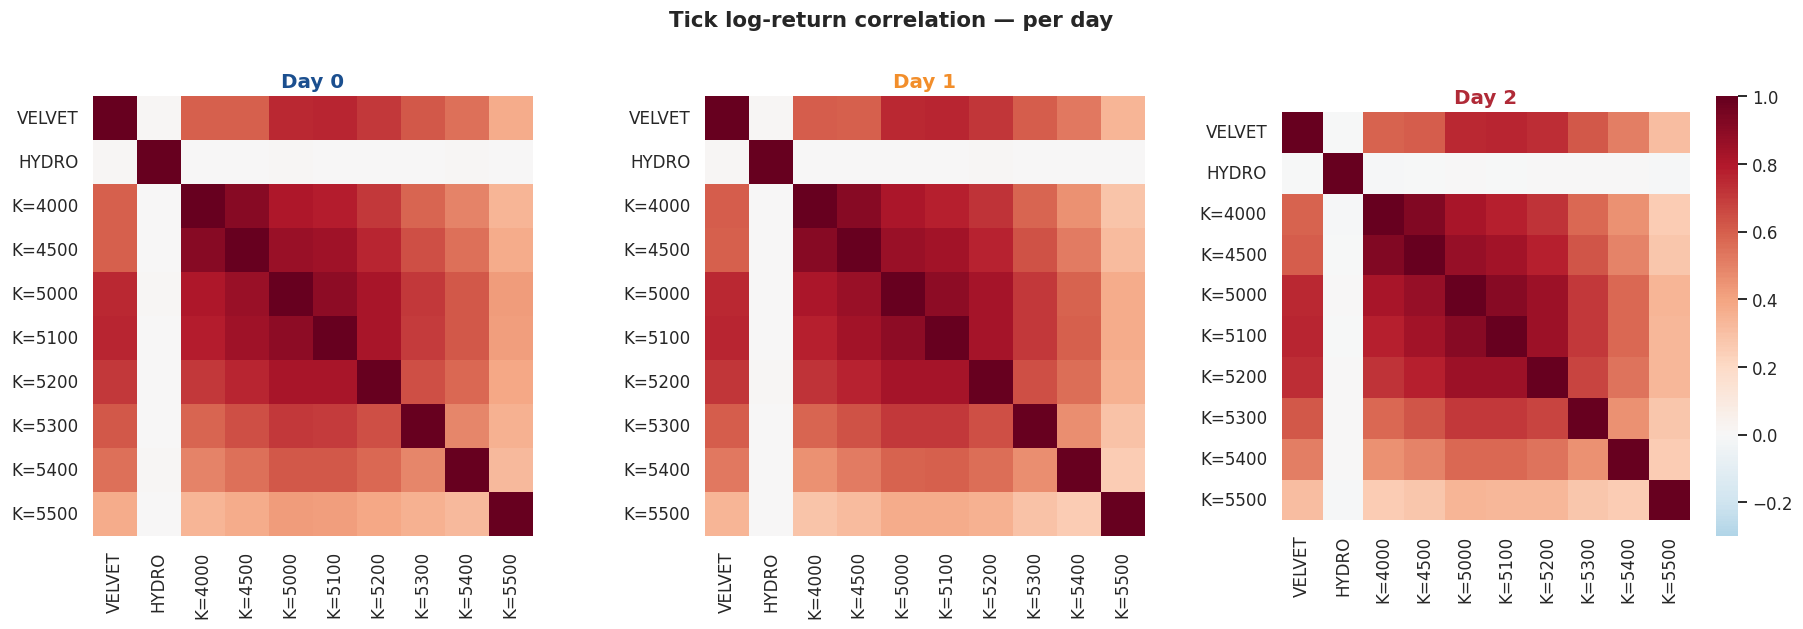

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))
for ax, d in zip(axes, (0,1,2)):
    wide = (prices[prices['day']==d]
              .pivot_table(index='timestamp', columns='product', values='mid_price'))
    rets = np.log(wide).diff().dropna(how='all')
    # Drop the floored strikes that barely move
    rets = rets.loc[:, rets.std() > 0]
    corr = rets.corr().reindex(index=[c for c in order if c in rets.columns],
                               columns=[c for c in order if c in rets.columns])
    sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-0.3, vmax=1,
                square=True, cbar=(d==2),
                xticklabels=[c.replace('VEV_','K=').replace(UNDERLYING,'VELVET').replace('HYDROGEL_PACK','HYDRO') for c in corr.columns],
                yticklabels=[c.replace('VEV_','K=').replace(UNDERLYING,'VELVET').replace('HYDROGEL_PACK','HYDRO') for c in corr.index])
    ax.set_title(f'Day {d}', color=DAY_COLORS[d])
    ax.set_xlabel(''); ax.set_ylabel('')
fig.suptitle('Tick log-return correlation — per day', y=1.03, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Option-vs-underlying scatter hexbin

For each near-the-money strike, the joint distribution of (S, option mid). Bone-dry call options would sit on a hockey stick; the thickness of the cloud is the time-value.

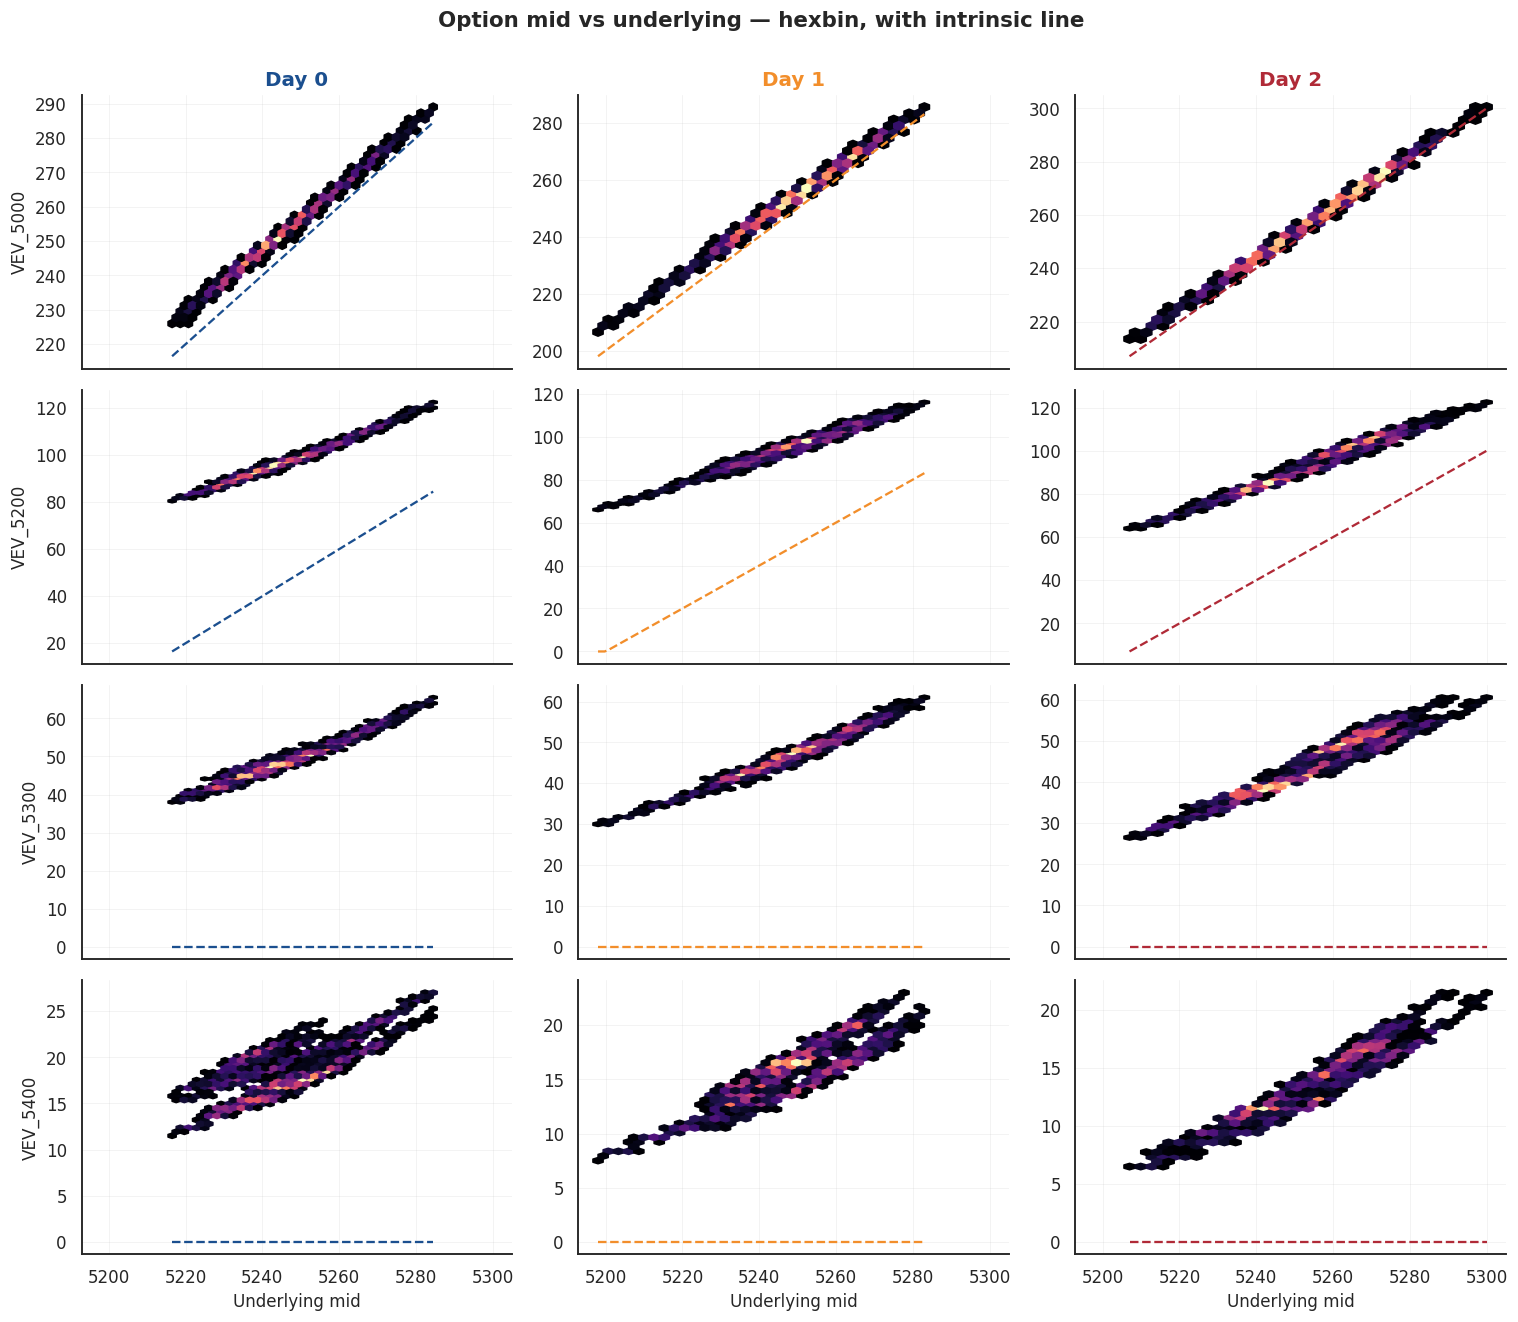

In [10]:
focus_strikes = [5000, 5200, 5300, 5400]
fig, axes = plt.subplots(len(focus_strikes), 3, figsize=(14, 3*len(focus_strikes)), sharex=True)
for row_i, k in enumerate(focus_strikes):
    for col_i, d in enumerate((0,1,2)):
        ax = axes[row_i, col_i]
        day_df = prices[prices['day']==d]
        und = day_df[day_df['product']==UNDERLYING][['timestamp','mid_price']].rename(columns={'mid_price':'S'})
        opt = day_df[day_df['product']==f'VEV_{k}'][['timestamp','mid_price']].rename(columns={'mid_price':'C'})
        m = und.merge(opt, on='timestamp')
        hb = ax.hexbin(m['S'], m['C'], gridsize=32, mincnt=1, cmap='magma')
        # intrinsic line
        s_range = np.linspace(m['S'].min(), m['S'].max(), 100)
        ax.plot(s_range, np.maximum(s_range - k, 0), color=DAY_COLORS[d], lw=1.5, ls='--', label='intrinsic')
        if row_i == 0:
            ax.set_title(f'Day {d}', color=DAY_COLORS[d])
        if col_i == 0:
            ax.set_ylabel(f'VEV_{k}')
        if row_i == len(focus_strikes)-1:
            ax.set_xlabel('Underlying mid')
fig.suptitle('Option mid vs underlying — hexbin, with intrinsic line', y=1.00, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Trade activity — who's trading what, when

Quantity traded per product stacked by day (left); time-of-day trade intensity per day (right).

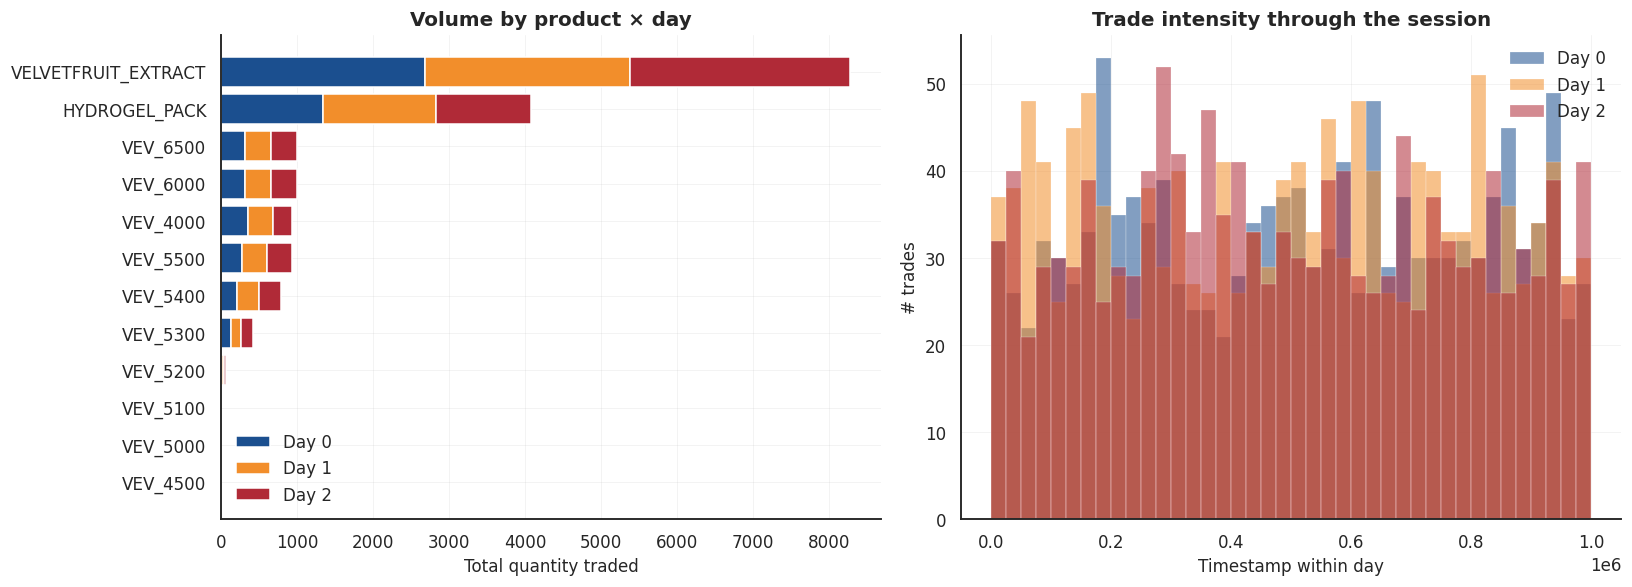

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: stacked bar of total volume
vol = (trades.groupby(['symbol','day'])['quantity']
              .sum().unstack('day').fillna(0))
vol_order = vol.sum(axis=1).sort_values(ascending=True).index
vol = vol.loc[vol_order]
left = np.zeros(len(vol))
y = np.arange(len(vol))
for d in (0,1,2):
    if d in vol.columns:
        axes[0].barh(y, vol[d].values, left=left, color=DAY_COLORS[d], label=f'Day {d}', edgecolor='white')
        left += vol[d].values
axes[0].set_yticks(y); axes[0].set_yticklabels(vol.index)
axes[0].set_xlabel('Total quantity traded')
axes[0].set_title('Volume by product × day')
axes[0].legend(frameon=False)

# Right: time-of-day trade intensity
bins = np.linspace(0, 1_000_000, 41)
for d in (0,1,2):
    t = trades[trades['day']==d]['timestamp']
    axes[1].hist(t, bins=bins, color=DAY_COLORS[d], alpha=0.55, label=f'Day {d}', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Timestamp within day')
axes[1].set_ylabel('# trades')
axes[1].set_title('Trade intensity through the session')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## 10. Order-book depth over time — underlying

Stack the top-3 bid and ask volumes around the mid. Thickness of the cloud = liquidity; the gap at the center is the spread.

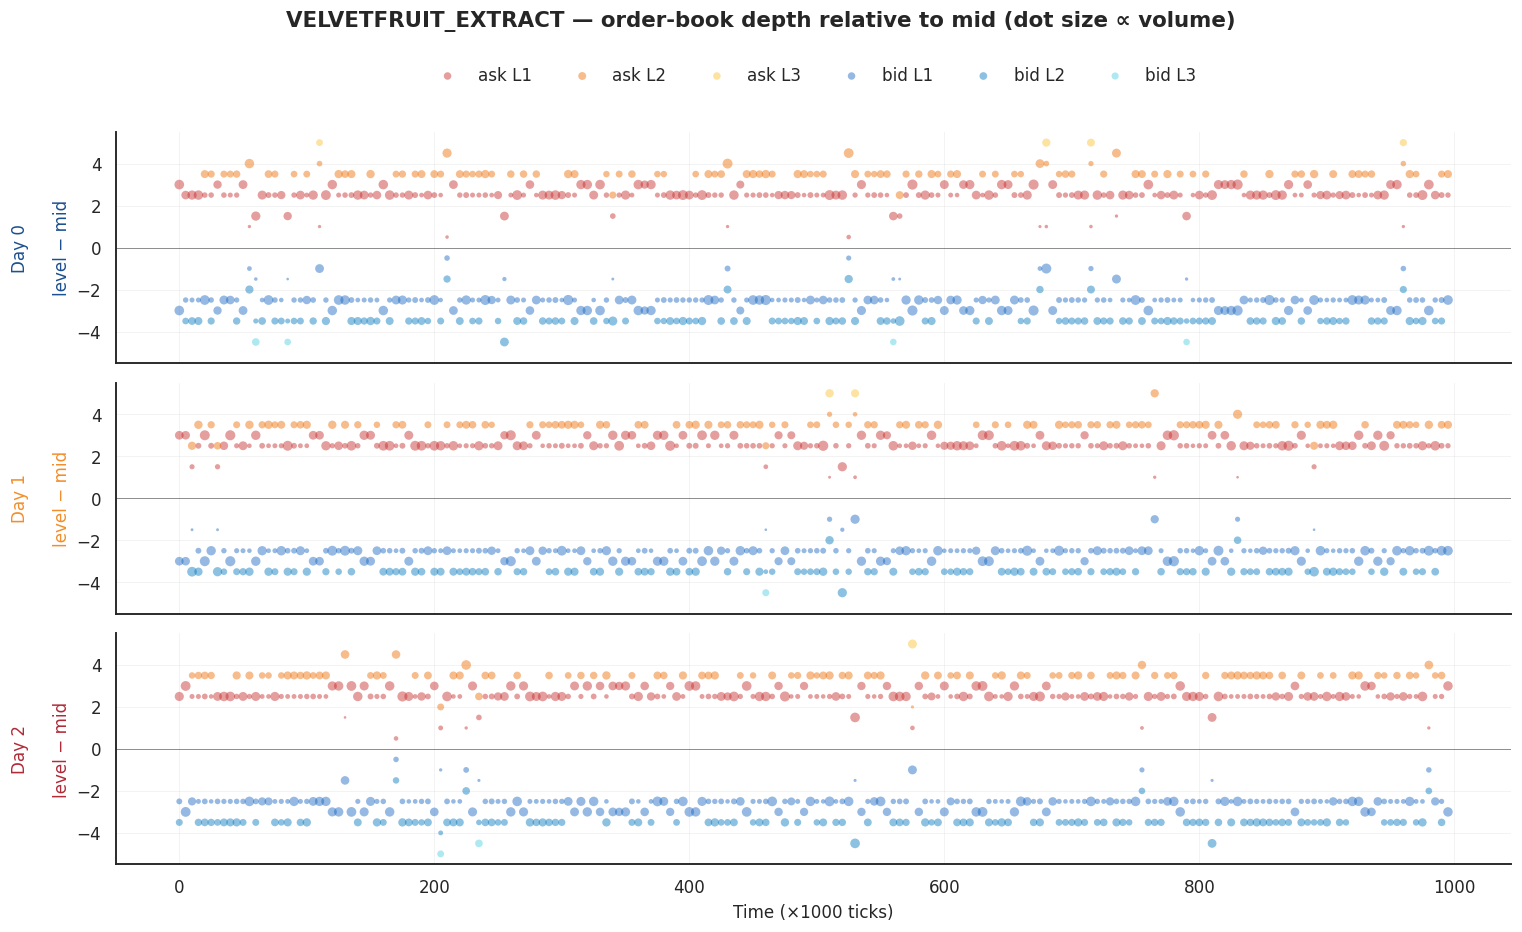

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8.5), sharex=True, sharey=True)
DOWNSAMPLE = 50  # every Nth tick
for ax, d in zip(axes, (0,1,2)):
    sub = prices[(prices['product']==UNDERLYING) & (prices['day']==d)].iloc[::DOWNSAMPLE]
    mid = sub['mid_price'].values
    t = sub['timestamp'].values / 1000
    # ask side: plot stacked ask levels as positive offsets from mid, weight by volume
    for lvl, col in zip((1,2,3), ['#c62828','#ef6c00','#fbc02d']):
        ap = sub[f'ask_price_{lvl}'].values
        av = sub[f'ask_volume_{lvl}'].fillna(0).values
        mask = ~np.isnan(ap)
        ax.scatter(t[mask], (ap-mid)[mask], s=av[mask]*0.6, c=col, alpha=0.45, edgecolors='none', label=f'ask L{lvl}' if d==0 else None)
    for lvl, col in zip((1,2,3), ['#1565c0','#0277bd','#4dd0e1']):
        bp = sub[f'bid_price_{lvl}'].values
        bv = sub[f'bid_volume_{lvl}'].fillna(0).values
        mask = ~np.isnan(bp)
        ax.scatter(t[mask], (bp-mid)[mask], s=bv[mask]*0.6, c=col, alpha=0.45, edgecolors='none', label=f'bid L{lvl}' if d==0 else None)
    ax.axhline(0, color='k', lw=0.6, alpha=0.5)
    ax.set_ylabel(f'Day {d}\n\nlevel − mid', color=DAY_COLORS[d])
axes[0].legend(ncol=6, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.35))
axes[-1].set_xlabel('Time (×1000 ticks)')
fig.suptitle(f'{UNDERLYING} — order-book depth relative to mid (dot size ∝ volume)', y=0.995, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Moneyness ribbon

For every tick, express each VEV price as a fraction of its strike-relative moneyness `ln(S/K)` and plot the mid / K ratio. Lines colored by day and shaded by strike get a clean waterfall.

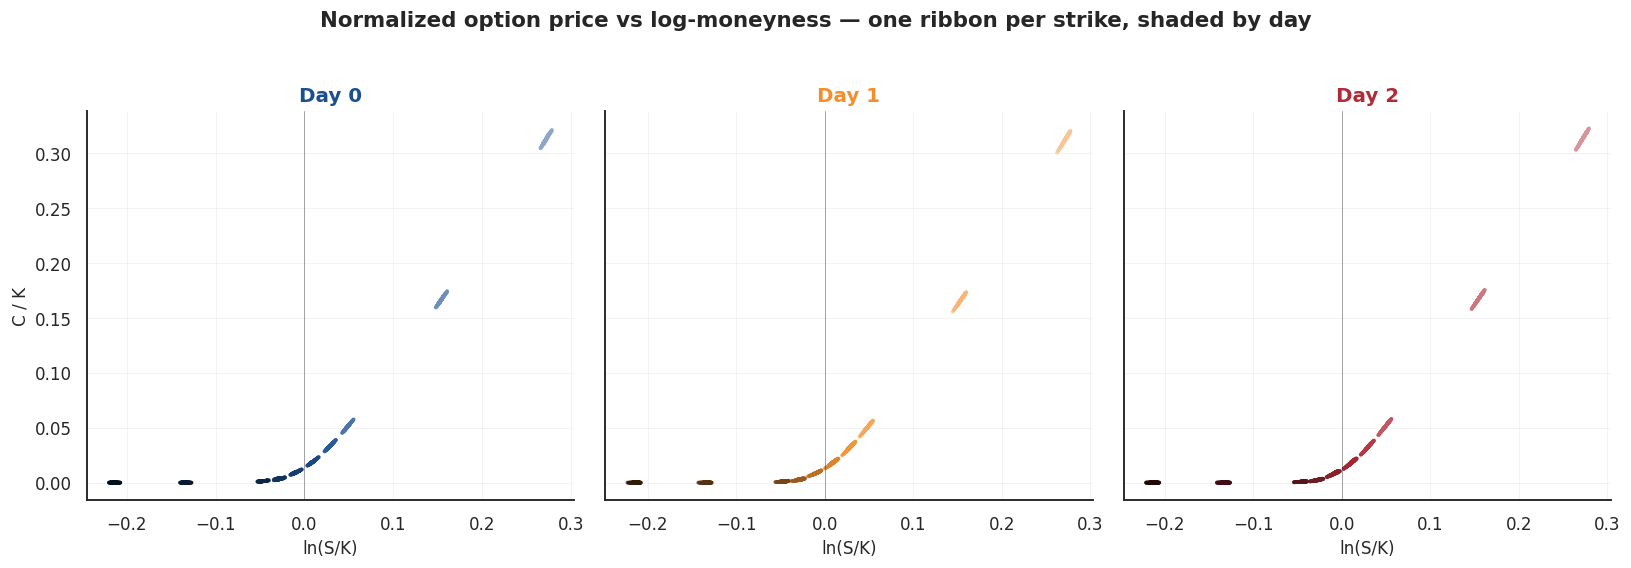

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, d in zip(axes, (0,1,2)):
    day_df = prices[prices['day']==d]
    und = day_df[day_df['product']==UNDERLYING].set_index('timestamp')['mid_price']
    base_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'day{d}', ['white', DAY_COLORS[d], 'black'])
    strike_colors = base_cmap(np.linspace(0.25, 0.9, len(VEV_STRIKES)))
    for color, k in zip(strike_colors, VEV_STRIKES):
        opt = day_df[day_df['product']==f'VEV_{k}'].set_index('timestamp')['mid_price']
        merged = pd.concat({'S': und, 'C': opt}, axis=1).dropna()
        if merged.empty: continue
        m = np.log(merged['S']/k)
        y = merged['C'] / k
        # every Nth point
        ax.scatter(m.values[::40], y.values[::40], c=[color], s=6, alpha=0.7, edgecolors='none')
    ax.set_title(f'Day {d}', color=DAY_COLORS[d])
    ax.set_xlabel('ln(S/K)')
    if d==0: ax.set_ylabel('C / K')
    ax.axvline(0, color='k', lw=0.6, alpha=0.4)
fig.suptitle('Normalized option price vs log-moneyness — one ribbon per strike, shaded by day', y=1.03, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Summary table

In [14]:
summary = (prices.groupby(['product','day'])['mid_price']
                 .agg(['mean','std','min','max'])
                 .round(2)
                 .reindex(order, level=0))
summary

mean    std     min      max
product             day                                 
VELVETFRUIT_EXTRACT 0    5246.51  13.68  5216.5   5284.5
                    1    5248.39  14.61  5198.0   5283.0
                    2    5255.39  16.99  5207.0   5300.0
HYDROGEL_PACK       0    9990.96  25.33  9928.0  10071.0
                    1    9992.06  37.61  9908.5  10079.0
                    2    9989.40  31.62  9891.0  10051.0
VEV_4000            0    1246.52  13.70  1215.0   1285.0
                    1    1248.41  14.63  1198.0   1283.0
                    2    1255.40  17.00  1207.0   1300.0
VEV_4500            0     746.52  13.69   716.5    785.0
                    1     748.41  14.63   698.5    783.0
                    2     755.40  16.99   708.5    799.5
VEV_5000            0     253.26  12.49   226.0    289.0
                    1     253.26  13.58   206.5    285.5
                    2     258.54  16.15   213.5    300.5
VEV_5100            0     168.11  10.95   145.0    200.5
                    1     164.98  11.94   125.0    193.5
                    2     167.33  14.81   127.5    205.5
VEV_5200            0      97.47   8.17    80.5    122.5
                    1      95.13   8.66    66.0    116.0
                    2      94.05  11.50    64.0    122.5
VEV_5300            0      48.89   5.18    38.0     65.5
                    1      46.91   5.47    30.0     61.0
                    2      44.48   7.06    26.5     60.5
VEV_5400            0      18.47   2.78    11.5     27.0
                    1      15.65   2.68     7.5     23.0
                    2      13.73   3.01     6.5     21.5
VEV_5500            0       8.06   1.24     5.5     12.5
                    1       6.57   1.33     3.0     10.0
                    2       5.29   1.40     2.5      9.5
VEV_6000            0       0.50   0.00     0.5      0.5
                    1       0.50   0.00     0.5      0.5
                    2       0.50   0.00     0.5      0.5
VEV_6500            0       0.50   0.00     0.5      0.5
                    1       0.50   0.00     0.5      0.5
                    2       0.50   0.00     0.5      0.5